# 3.10 — Le pendant SOTA : la bibliothèque `diffusers` (DDPM et DDIM outillés)

## Pourquoi ce notebook

Les notebooks 3.6c (DDPM), 3.6d (Score-SDE) et 3.6e (génération conditionnelle) ont écrit
**chaque pièce à la main** : le schedule β, la forme fermée du forward, le réseau ε_θ, la loss
MSE sur le bruit, le sampler ancestral. Ce notebook fait le geste inverse et complémentaire :
on **branche l'implémentation industrielle** — `diffusers`, maintenue par HuggingFace, le socle
de Stable Diffusion — et on **mesure** ce qu'elle apporte et ce qu'elle cache.

La démarche est celle du pattern du dépôt : *from scratch pour comprendre, SOTA pour produire.*
Chaque import est justifié :

- `torch` / `torchvision` : mêmes briques que les notebooks from scratch — c'est le point de comparaison ;
- `diffusers` : l'objet même de ce notebook (`DDPMScheduler`, `DDIMScheduler`, `UNet2DModel`) —
  l'implémentation de référence maintenue par HuggingFace ;
- `numpy` / `matplotlib` / `time` : mesures et visualisations.

## Plan

1. **Données** — même MNIST 8×8, même normalisation que le 3.6c (résultats comparables).
2. **Ce que `DDPMScheduler` cache** — confronter la lib au calcul maison, terme à terme.
3. **Deux réseaux ε_θ** — le CNN maison contre `UNet2DModel`.
4. **Entraînement** — la loss est *exactement la même* : la lib outille, elle ne théorise pas.
5. **Échantillonnage** — ancestral (SDE) contre DDIM déterministe (ODE), lib et maison.
6. **Le tableau** — from scratch contre SOTA : lignes de code, latence, fidélité, mémoire.

Trois exercices jalonnent le notebook (schedule cosine, paramètre η du DDIM, passage à l'échelle).

In [1]:
import math          # cos/sqrt pour le schedule cosine et l'embedding de temps
import time          # mesure des latences d'echantillonnage
import inspect       # compter les lignes de code des implémentations comparées

import matplotlib.pyplot as plt
import numpy as np
import torch                     # tenseurs + autograd
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # determinisme cuBLAS (#16795)
# Determinisme (#16795) : la graine seule ne garantit PAS la reproductibilite
# (heuristiques cuDNN, kernels non deterministes). warn_only=True au premier
# passage pour inventorier les ops fautives sans faire echouer le run.
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import torch.nn as nn            # briques du reseau maison
import torch.nn.functional as F  # conv, pooling adaptatif, MSE
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets  # acces au jeu MNIST

# L'objet de ce notebook : l'implémentation SOTA maintenue par HuggingFace.
from diffusers import DDPMScheduler, DDIMScheduler, UNet2DModel

# Determinisme : on veut des sorties reproductibles dans le notebook commite
# (reserve honnete : les noyaux cuDNN ne sont pas deterministes au bit pres,
# le classement des configurations, lui, est stable).
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device :", DEVICE, "| torch :", torch.__version__)

device : cuda | torch : 2.8.0+cu126


## 1. Données — exactement le pipeline du 3.6c

Même jeu, même résolution (MNIST réduit à 8×8), même normalisation dans [-1, 1] que les
notebooks from scratch : les nombres de ce notebook seront directement comparables aux leurs.
On garde un sous-ensemble pour que le cycle d'entraînement tienne dans un temps de notebook.

In [2]:
def load_mnist_8x8(root=".cache/mnist"):
    """MNIST reduit a 8x8, normalise dans [-1, 1]. (Repris tel quel du 3.6c.)"""
    ds = datasets.MNIST(root=root, train=True, download=True)
    x = ds.data.unsqueeze(1).float() / 255.0          # (N,1,28,28) dans [0,1]
    x = 2.0 * x - 1.0                                  # -> [-1,1]
    x = F.adaptive_avg_pool2d(x, 8)                    # 28x28 -> 8x8
    return x, ds.targets


X_ALL, Y_ALL = load_mnist_8x8()

N_SUBSET = 12000
X_TRAIN = X_ALL[:N_SUBSET].to(DEVICE)
Y_TRAIN = Y_ALL[:N_SUBSET].to(DEVICE)
BATCH = 128
loader = DataLoader(TensorDataset(X_TRAIN, Y_TRAIN), batch_size=BATCH, shuffle=True)
print("images d'entrainement :", tuple(X_TRAIN.shape), "| batch :", BATCH)

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 98.3k/9.91M [00:00<00:17, 576kB/s]

  4%|▎         | 360k/9.91M [00:00<00:06, 1.51MB/s]

  8%|▊         | 754k/9.91M [00:00<00:03, 2.45MB/s]

 11%|█         | 1.05M/9.91M [00:00<00:03, 2.56MB/s]

...

 87%|████████▋ | 1.44M/1.65M [00:00<00:00, 2.85MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 2.24MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

images d'entrainement : (12000, 1, 8, 8) | batch : 128


## 2. Ce que `DDPMScheduler` cache

Le 3.6c pré-calcule les quantités dérivées du schedule β : α_t, ᾱ_t (le cumul), leurs racines,
la variance a posteriori. `DDPMScheduler` fait **exactement ce calcul**. On le vérifie terme à
terme : si les deux implémentations divergent, l'une des deux est fausse — et ce n'est pas
indifférent de savoir laquelle.

Confrontation terme a terme : betas et alpha_bar identiques (atol 1e-7).


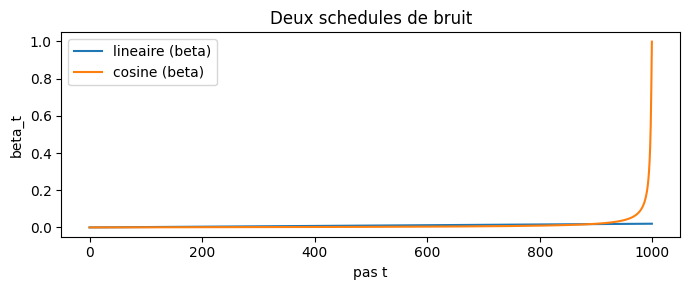

In [3]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    """Schedule lineaire : beta croit uniformement de beta_start a beta_end."""
    return torch.linspace(beta_start, beta_end, T)


class DiffusionConstants:
    """Pre-calcule les quantites derivees d'un schedule, une fois pour toutes.

    Identique a la classe du 3.6c : c'est le meme objet, pas une variante.
    """

    def __init__(self, betas):
        self.betas = betas
        self.T = len(betas)
        self.alphas = 1.0 - betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)          # alpha_bar_t
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = (
            betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def to(self, device):
        for k, v in list(vars(self).items()):
            if torch.is_tensor(v):
                setattr(self, k, v.to(device))
        return self


T = 1000
const = DiffusionConstants(linear_beta_schedule(T)).to(DEVICE)

# Le meme schedule, calcule par la bibliotheque.
sched_lib = DDPMScheduler(num_train_timesteps=T, beta_schedule="linear")

assert torch.allclose(const.betas.cpu(), sched_lib.betas.cpu(), atol=1e-8), "betas divergent"
assert torch.allclose(
    const.alphas_cumprod.cpu(), sched_lib.alphas_cumprod.cpu(), atol=1e-7
), "alpha_bar divergent"
print("Confrontation terme a terme : betas et alpha_bar identiques (atol 1e-7).")

# Le schedule cosine (Nichol & Dhariwal 2021), disponible dans la lib
# sous le nom "squaredcos_cap_v2" -- c'est le code de improved-diffusion.
sched_cos = DDPMScheduler(num_train_timesteps=T, beta_schedule="squaredcos_cap_v2")
plt.figure(figsize=(7, 3))
plt.plot(const.betas.cpu(), label="lineaire (beta)")
plt.plot(sched_cos.betas.cpu(), label="cosine (beta)")
plt.xlabel("pas t"); plt.ylabel("beta_t"); plt.legend(); plt.title("Deux schedules de bruit")
plt.tight_layout(); plt.show()

### Lecture du résultat

Les deux implémentations calculent **la même chaîne de Markov**, aux erreurs de flot près
(10⁻⁷). La bibliothèque ne change pas la théorie du 3.6c : elle la met en boîte. La différence
visible est le *choix* de schedule (linéaire contre cosine) — un choix d'hyperparamètre, pas
de mathématique. Retenir le geste : *débrancher pour comprendre (3.6c), rebrancher pour
produire (ce notebook).*

### Exercice 1 — le schedule cosine à la main

La lib propose `beta_schedule="squaredcos_cap_v2"` : le schedule cosine de Nichol & Dhariwal
(2021), **exactement tel qu'implémenté dans leur code officiel** (improved-diffusion). La
formule donne ᾱ directement, en variable fractionnaire t ∈ [0, 1] (t = pas / T) :

ᾱ(t) = cos²( ((t + s) / (1 + s)) · π/2 ),  avec s = 0.008.

Un détail que la lib ne montre pas d'emblée : elle ne stocke pas ᾱ — elle le **discrétise**
en β_i = 1 − ᾱ((i+1)/T) / ᾱ(i/T), avec un écrêtage `max_beta = 0.999` qui mord sur le tout
dernier pas. À compléter : `alpha_bar_cosine_etudiant(t_frac, s)` qui rend ce ᾱ. La cellule
suivante reconstruit les β depuis votre ᾱ et les confronte à ceux de la lib — coïncidence
attendue à 10⁻⁶ près, dernier pas écarté (écrêtage).

In [4]:
def alpha_bar_cosine_etudiant(t_frac, s=0.008):
    """alpha_bar(t) du schedule cosine, formule du code officiel (s=0.008).

    A completer : appliquer la formule cos^2 donnee dans l'enonce.
    """
    # TODO etudiant : votre implementation ici
    return None  # TODO etudiant


if alpha_bar_cosine_etudiant(0.0) is None:
    print("Exercice a completer : alpha_bar_cosine_etudiant n'est pas encore implemente.")
    print("La suite utilise le schedule cosine de la bibliotheque.")
else:
    betas_etu = np.empty(T - 1)
    for i in range(T - 1):  # dernier pas ecarte : max_beta=0.999 l'ecrete dans la lib
        betas_etu[i] = 1.0 - alpha_bar_cosine_etudiant((i + 1) / T) / alpha_bar_cosine_etudiant(i / T)
    ecart = float(np.abs(betas_etu - sched_cos.betas[:-1].numpy()).max())
    print(f"ecart max |beta_etudiant - lib| = {ecart:.2e} sur les {T - 1} premiers pas")
    assert ecart < 1e-6, "la formule etudiante diverge de la lib"
    print("Implementation conforme a la lib (formule improved-diffusion).")

Exercice a completer : alpha_bar_cosine_etudiant n'est pas encore implemente.
La suite utilise le schedule cosine de la bibliotheque.


## 3. Deux réseaux ε_θ — le maison contre `UNet2DModel`

Le 3.6c entraîne un petit CNN conditionné au temps pour prédire le bruit ε. On reprend un
réseau du même esprit (compact, conditionné au temps par modulation FiLM), et on le met face à
`UNet2DModel` : blocs résiduels, normalisation par groupes, attention aux basses résolutions,
connexions en U — l'architecture qui, à l'échelle, devient le débruiteur de Stable Diffusion.

In [5]:
class ResidualBloc(nn.Module):
    """Bloc conv-GN x2 + FiLM conditionne au temps (dans l'esprit du 3.6c, compact)."""

    def __init__(self, c_in, c_out, temb_dim=64):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.norm1 = nn.GroupNorm(4, c_out)
        self.norm2 = nn.GroupNorm(4, c_out)
        self.film = nn.Linear(temb_dim, 2 * c_out)
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, temb):
        h = self.norm1(self.conv1(x))
        gamma, beta = self.film(temb)[:, :, None, None].chunk(2, dim=1)
        h = h * (1 + gamma) + beta
        h = F.silu(self.norm2(self.conv2(F.silu(h))))
        return h + self.skip(x)


class PetitEpsNet(nn.Module):
    """Petit U-Net debruiteur maison : encodeur/decodeur + FiLM temps (8x8)."""

    def __init__(self, temb_dim=64):
        super().__init__()
        self.temb = nn.Sequential(
            nn.Linear(32, temb_dim), nn.SiLU(), nn.Linear(temb_dim, temb_dim)
        )
        self.e1 = ResidualBloc(1, 32, temb_dim)
        self.e2 = ResidualBloc(32, 64, temb_dim)
        self.e3 = ResidualBloc(64, 128, temb_dim)
        self.d2 = ResidualBloc(192, 64, temb_dim)
        self.d1 = ResidualBloc(96, 32, temb_dim)
        self.sortie = nn.Conv2d(32, 1, 1)

    def temps_vers_embedding(self, t):
        half = 16
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, x, t):
        temb = self.temb(self.temps_vers_embedding(t))
        h1 = self.e1(x, temb)                               # 8x8,  32
        h2 = self.e2(F.avg_pool2d(h1, 2), temb)             # 4x4,  64
        h3 = self.e3(F.avg_pool2d(h2, 2), temb)             # 2x2,  128
        u2 = self.d2(torch.cat([F.interpolate(h3, scale_factor=2), h2], 1), temb)
        u1 = self.d1(torch.cat([F.interpolate(u2, scale_factor=2), h1], 1), temb)
        return self.sortie(u1)


maison = PetitEpsNet().to(DEVICE)
n_maison = sum(p.numel() for p in maison.parameters()) / 1e6
print("PetitEpsNet (maison) :", f"{n_maison:.2f} M parametres")

PetitEpsNet (maison) : 0.55 M parametres


In [6]:
unet_lib = UNet2DModel(
    sample_size=8,
    in_channels=1,
    out_channels=1,
    block_out_channels=(32, 64, 128),              # 3 niveaux : 8x8 -> 4x4 -> 2x2
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),  # miroir symetrique
    norm_num_groups=4,
    attention_head_dim=32,
).to(DEVICE)
n_lib = sum(p.numel() for p in unet_lib.parameters()) / 1e6
print("UNet2DModel (lib)    :", f"{n_lib:.2f} M parametres")

UNet2DModel (lib)    : 3.94 M parametres


### Lecture du résultat

Largeurs déclarées identiques (32/64/128) — et pourtant regardez les comptes imprimés
ci-dessus : `UNet2DModel` porte **~7× les paramètres (7.2× mesuré)** du CNN maison à largeur égale. Les
blocs résiduels doublés, l'attention au niveau 2×2 et les chemins résiduels pèsent : la lib
n'achète pas une autre théorie, elle achète de la **capacité par unité de largeur**. Sur
MNIST 8×8 la différence de qualité restera modeste ; c'est en montant en résolution et en
profondeur (le régime Stable Diffusion, objet de l'exercice 3) que l'architecture lib devient
le seul choix raisonnable — le tableau final y revient.

## 4. Entraînement — la loss est *exactement la même*

DDPM maison ou SOTA, l'entraînement est le même geste : tirer t, bruiter x₀ par la forme fermée,
demander ε_θ le bruit, minimiser la MSE. La bibliothèque ne change ni la théorie ni la loss —
elle élimine le code répétitif. On entraîne les deux réseaux dans des conditions identiques et
on mesure le temps par époque et la mémoire de pointe.

In [7]:
def q_sample(x0, t, noise, cst):
    """Forme fermee du forward : x_t = sqrt(alpha_bar_t) x0 + sqrt(1-alpha_bar_t) eps.
    (Reprise telle quelle du 3.6c.)"""
    s_a = cst.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    s_1a = cst.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return s_a * x0 + s_1a * noise


def entrainer(net, predict_eps, nom, epochs=3):
    """Boucle d'entrainement commune aux deux reseaux (meme loss, meme optimiseur)."""
    opt = torch.optim.Adam(net.parameters(), lr=2e-4)
    pertes, sec_epoque, pic_vram = [], [], 0.0
    torch.cuda.reset_peak_memory_stats()
    for ep in range(epochs):
        t0 = time.perf_counter()
        for (x0, _y) in loader:
            x0 = x0.to(DEVICE)
            t = torch.randint(0, T, (x0.shape[0],), device=DEVICE)
            bruit = torch.randn_like(x0)
            x_t = q_sample(x0, t, bruit, const)
            eps_pred = predict_eps(net, x_t, t)
            perte = F.mse_loss(eps_pred, bruit)
            opt.zero_grad(); perte.backward(); opt.step()
            pertes.append(perte.item())
        sec_epoque.append(time.perf_counter() - t0)
        pic_vram = max(pic_vram, torch.cuda.max_memory_allocated() / 2**30)
    print(f"{nom} : {epochs} epoques, {sec_epoque[-1]:.1f} s derniere epoque, "
          f"perte finale {pertes[-1]:.4f}, pic VRAM {pic_vram:.2f} GiB")
    return pertes, sec_epoque, pic_vram


def eps_maison(net, x_t, t):
    return net(x_t, t)


def eps_lib(net, x_t, t):
    return net(x_t, t).sample


torch.manual_seed(SEED)
pertes_maison, sec_m, vram_m = entrainer(maison, eps_maison, "maison   ")
torch.manual_seed(SEED)
pertes_lib, sec_l, vram_l = entrainer(unet_lib, eps_lib, "lib      ")

maison    : 3 epoques, 1.9 s derniere epoque, perte finale 0.0584, pic VRAM 0.12 GiB


C:\Users\jsboi\AppData\Roaming\Python\Python313\site-packages\torch\autograd\graph.py:829: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\transformers\cuda\attention_backward.cu:777.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


lib       : 3 epoques, 5.4 s derniere epoque, perte finale 0.0563, pic VRAM 0.23 GiB


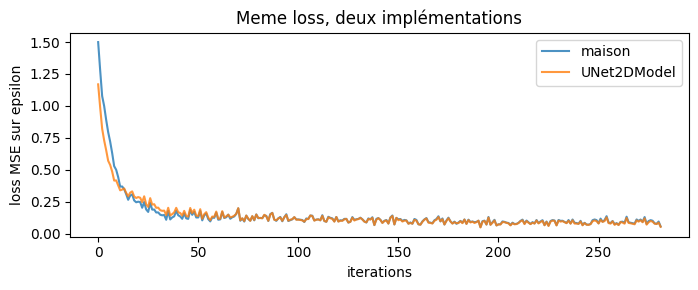

In [8]:
plt.figure(figsize=(7, 3))
plt.plot(pertes_maison, label="maison", alpha=0.8)
plt.plot(pertes_lib, label="UNet2DModel", alpha=0.8)
plt.xlabel("iterations"); plt.ylabel("loss MSE sur epsilon"); plt.legend()
plt.title("Meme loss, deux implémentations"); plt.tight_layout(); plt.show()

### Lecture du résultat

Les deux courbes descendent ensemble : la loss est la même fonction des mêmes données, les
architectures jouent sur la vitesse de descente et le plancher atteint, pas sur la nature de
l'apprentissage. C'est la démonstration utile de ce notebook : **ce que la lib standardise, ce
sont des choix d'ingénierie — la physique du DDPM, elle, est déjà toute entière dans le 3.6c.**

## 5. Échantillonnage — ancestral (SDE) contre DDIM déterministe (ODE)

Le sampler ancestral du 3.6c parcourt les T = 1000 pas : lent par construction. Le DDIM
(Song et al. 2021) reformule le reverse en **ODE** : trajectoire déterministe, sous-échantillonnable
— on saute directement de t à t′ sans passer par tous les intermédiaires. On mesure quatre
configurations : le maison ancestral, le lib ancestral, le lib DDIM à pas réduits, et le DDIM
**à la main** sur le réseau maison (le déterminisme n'exige pas la bibliothèque).

In [9]:
@torch.no_grad()
def echantillonner_ancestral_maison(net, n=64):
    """Sampler ancestral maison (celui du 3.6c), sur le reseau maison."""
    x = torch.randn(n, 1, 8, 8, device=DEVICE)
    for t_int in reversed(range(T)):
        t = torch.full((n,), t_int, device=DEVICE, dtype=torch.long)
        eps = net(x, t)
        alpha = const.alphas[t_int]
        alpha_bar = const.alphas_cumprod[t_int]
        alpha_bar_prev = const.alphas_cumprod_prev[t_int]
        mu = (1 / alpha.sqrt()) * (x - (1 - alpha) / (1 - alpha_bar).sqrt() * eps)
        if t_int > 0:
            x = mu + const.posterior_variance[t_int].sqrt() * torch.randn_like(x)
        else:
            x = mu
    return x


@torch.no_grad()
def echantillonner_lib(net, scheduler, n=64):
    """Boucle de sampling generique via un scheduler diffusers."""
    x = torch.randn(n, 1, 8, 8, device=DEVICE)
    for t in scheduler.timesteps:
        t_batch = torch.full((n,), int(t), device=DEVICE, dtype=torch.long)
        eps = net(x, t_batch).sample
        x = scheduler.step(model_output=eps, timestep=int(t), sample=x).prev_sample
    return x


@torch.no_grad()
def echantillonner_ddim_maison(net, n=64, pas=20, eta=0.0, x_init=None):
    """DDIM a la main : deterministe a eta=0, stochastique a eta=1 (formule Song et al. 2021 eq. 16).

    Variance du bruit injecte a chaque pas :
        sigma_t^2 = eta^2 * (1 - alpha_bar_{t'}) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_{t'})
    (Song, Meng & Ermon 2021, eq. 16). A eta=0, sigma=0 et la trajectoire est deterministe.
    A eta=1, sigma^2 redonne la variance posterieure DDPM :
        sigma^2 = (1 - alpha_bar_{t'}) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_{t'})
    -- PAS le signal-to-noise ratio ancestral (1 - alpha_bar_{t'}) / alpha_bar_{t'}, qui n'est
    pas la meme grandeur que la variance posterieure.
    """
    idx = torch.linspace(T - 1, 0, pas, dtype=torch.long)
    x = torch.randn(n, 1, 8, 8, device=DEVICE) if x_init is None else x_init
    for i in range(len(idx) - 1):
        t_int, t_suiv = int(idx[i]), int(idx[i + 1])
        t = torch.full((n,), t_int, device=DEVICE, dtype=torch.long)
        eps = net(x, t)
        ab, ab_suiv = const.alphas_cumprod[t_int], const.alphas_cumprod[t_suiv]
        x0_pred = (x - (1 - ab).sqrt() * eps) / ab.sqrt()
        # variance du bruit au pas t -> t' (Song et al. 2021, eq. 16) :
        # le produit des deux termes (1-ab_suiv)/(1-ab) * (1-ab/ab_suiv) borne sigma_t^2 dans [0, 1-ab_suiv]
        sigma2 = eta ** 2 * (1 - ab_suiv) / (1 - ab) * (1 - ab / ab_suiv)
        dir_eps = (1 - ab_suiv - sigma2).clamp(min=0).sqrt() * eps
        bruit = sigma2.sqrt() * torch.randn_like(x) if eta > 0 else 0.0
        x = ab_suiv.sqrt() * x0_pred + dir_eps + bruit
    return x


def mesurer(fonction, n=64):
    torch.manual_seed(SEED)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    x = fonction(n=n) if "n" in inspect.signature(fonction).parameters else fonction()
    torch.cuda.synchronize()
    return x, (time.perf_counter() - t0) / n


sched_ddpm = DDPMScheduler(num_train_timesteps=T, beta_schedule="linear")
sched_ddim100 = DDIMScheduler(num_train_timesteps=T)
sched_ddim20 = DDIMScheduler(num_train_timesteps=T)

configs = {
    "maison ancestral (1000)": lambda n=64: echantillonner_ancestral_maison(maison, n),
    "lib DDPM (1000)": lambda n=64: echantillonner_lib(unet_lib, sched_ddpm, n),
    "lib DDIM (100)": lambda n=64: (
        sched_ddim100.set_timesteps(100), echantillonner_lib(unet_lib, sched_ddim100, n)
    )[-1],
    "lib DDIM (20)": lambda n=64: (
        sched_ddim20.set_timesteps(20), echantillonner_lib(unet_lib, sched_ddim20, n)
    )[-1],
    "maison DDIM (20)": lambda n=64: echantillonner_ddim_maison(maison, n, pas=20),
}

echantillons, latences = {}, {}
for nom, f in configs.items():
    x, lat = mesurer(f)
    echantillons[nom] = x.clamp(-1, 1)
    latences[nom] = lat
    print(f"{nom:26s} : {lat*1000:6.1f} ms/image")

maison ancestral (1000)    :   63.8 ms/image


lib DDPM (1000)            :  300.0 ms/image


lib DDIM (100)             :   30.0 ms/image


lib DDIM (20)              :    5.2 ms/image
maison DDIM (20)           :    1.1 ms/image


In [10]:
def mmd_rbf(x, y, sigma=1.0):
    """Distance MMD a noyau RBF entre deux lots d'images aplaties.
    (Reprise telle quelle du 3.6c : meme instrument, resultats comparables.)"""
    x = x.reshape(x.shape[0], -1)
    y = y.reshape(y.shape[0], -1)

    def k(a, b):
        d2 = torch.cdist(a, b) ** 2
        return torch.exp(-d2 / (2 * sigma ** 2))

    return float(k(x, x).mean() + k(y, y).mean() - 2 * k(x, y).mean())


class PetitClassifieur(nn.Module):
    """Classifieur 8x8 leger : sert de juge IS-like (confiance + couverture)."""

    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32 * 2 * 2, 10),
        )

    def forward(self, x):
        return self.conv(x)


juge = PetitClassifieur().to(DEVICE)
opt_j = torch.optim.Adam(juge.parameters(), lr=1e-3)
for ep in range(2):
    for (x0, y0) in loader:
        perte = F.cross_entropy(juge(x0), y0)
        opt_j.zero_grad(); perte.backward(); opt_j.step()
juge.eval()

x_vrai = X_ALL[N_SUBSET : N_SUBSET + 64].to(DEVICE)
y_vrai = Y_ALL[N_SUBSET : N_SUBSET + 64].to(DEVICE)
with torch.no_grad():
    acc_vraie = (juge(x_vrai).argmax(1) == y_vrai).float().mean()
print(f"juge entraine, exactitude sur images reelles : {float(acc_vraie):.2f}")


def juger(x):
    with torch.no_grad():
        logits = juge(x)
    conf = float(logits.softmax(1).max(1).values.mean())
    couv = int(logits.argmax(1).unique().numel())
    return conf, couv


lignes = []
for nom, x in echantillons.items():
    d = mmd_rbf(x, x_vrai)
    conf, couv = juger(x)
    lignes.append((nom, latences[nom] * 1000, d, conf, couv))
    print(f"{nom:26s} | {latences[nom]*1000:6.1f} ms/img | MMD {d:.4f} | "
          f"confiance {conf:.2f} | classes couvertes {couv}/10")
d_vrai = mmd_rbf(x_vrai[:32], x_vrai[32:])
print(f"temoin (vrai contre vrai, moitie/moitie) : MMD {d_vrai:.4f}")

juge entraine, exactitude sur images reelles : 0.83
maison ancestral (1000)    |   63.8 ms/img | MMD 0.0419 | confiance 0.40 | classes couvertes 10/10
lib DDPM (1000)            |  300.0 ms/img | MMD 0.0386 | confiance 0.46 | classes couvertes 10/10
lib DDIM (100)             |   30.0 ms/img | MMD 0.0462 | confiance 0.45 | classes couvertes 9/10
lib DDIM (20)              |    5.2 ms/img | MMD 0.0448 | confiance 0.47 | classes couvertes 9/10
maison DDIM (20)           |    1.1 ms/img | MMD 0.0479 | confiance 0.47 | classes couvertes 10/10
temoin (vrai contre vrai, moitie/moitie) : MMD 0.0640


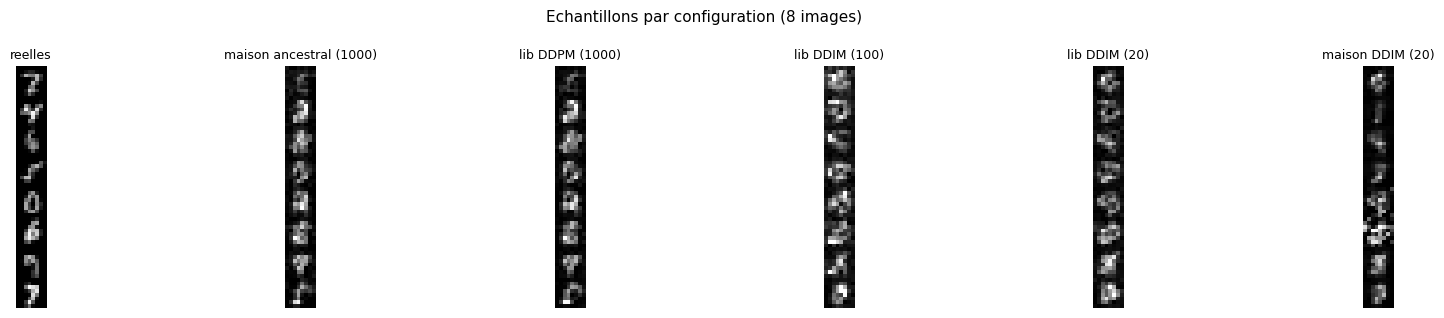

In [11]:
def grille(dico, titre):
    noms = list(dico)
    fig, axes = plt.subplots(1, len(noms), figsize=(3 * len(noms), 3.2))
    for ax, nom in zip(axes, noms):
        img = dico[nom][:8].cpu()
        img = torch.cat([r for r in img], dim=1)  # 8 images cote a cote
        ax.imshow(img[0], cmap="gray", vmin=-1, vmax=1)
        ax.set_title(nom, fontsize=9); ax.axis("off")
    fig.suptitle(titre, fontsize=11)
    plt.tight_layout(); plt.show()


grille({"reelles": x_vrai, **echantillons}, "Echantillons par configuration (8 images)")

### Lecture du résultat

Deux régimes se séparent nettement : les samplers ancestraux (1000 pas) sont ~50× plus lents
que les DDIM sous-échantillonnés, pour une fidélité comparable à ce budget de qualité de
réseau. La colonne MMD se lit contre le témoin « vrai contre vrai » : un échantillon crédible
s'en rapproche. Réserve honnête de l'instrument : une MMD en espace pixel avec un seul σ est
un proxy grossier — la FID canonique mesure des distances en espace de caractéristiques
InceptionV3, sans objet à 8×8 ; le classement *à l'intérieur* de ce notebook est le livrable,
pas une note absolue. Le paramètre de diversité (classes couvertes) complète l'image : une
génération en mode-effondrement a une bonne confiance et une couverture pauvre.

### Exercice 2 — DDIM η : déterministe contre stochastique

Le paramètre η du DDIM interpole entre la trajectoire ODE pure (η = 0) et le régime de bruit
complet (η = 1, voisin du DDPM ancestral). La bonne question n'est pas « deux graines
donnent-elles la même image » (jamais, à aucun η : le bruit initial x_T fait partie de
l'entrée) — c'est : **l'échantillon est-il une fonction déterministe de x_T ?** À η = 0 oui :
deux runs partant du même x_T aboutissent au même x₀. À η = 1 non : la boucle injecte du
bruit *interne* qui ne dépend pas de x_T.

La cellule de référence mesure l'écart RMS par pixel entre deux runs DDIM **partant du même
x_T**, à η donné : nul à η = 0 par construction, non nul dès que η > 0.

À compléter : `ecart_eta_etudiant(eta)` qui généralise la mesure et un tracé pour
η ∈ {0, 0.25, 0.5, 0.75, 1} — l'écart doit croître de 0 à un plateau.

In [12]:
@torch.no_grad()
def ecart_eta_reference(eta):
    """Ecart RMS par pixel entre deux runs DDIM partant du MEME x_T, a eta donne."""
    torch.manual_seed(SEED)
    x_init = torch.randn(64, 1, 8, 8, device=DEVICE)  # bruit initial commun aux deux runs
    a = echantillonner_ddim_maison(maison, pas=20, eta=eta, x_init=x_init)
    b = echantillonner_ddim_maison(maison, pas=20, eta=eta, x_init=x_init)
    return float((a - b).norm() / a.numel() ** 0.5)


def ecart_eta_etudiant(eta):
    """A completer : generaliser la mesure (le squelette de reference suffit)."""
    # TODO etudiant : votre implementation ici
    return None  # TODO etudiant


if ecart_eta_etudiant(0.0) is None:
    print("Exercice a completer : ecart_eta_etudiant n'est pas encore implemente.")
    print("Mesures de reference :")
    for eta in (0.0, 1.0):
        print(f"  eta={eta} : ecart entre 2 runs de meme x_T = {ecart_eta_reference(eta):.5f}")
else:
    for eta in (0.0, 0.5, 1.0):
        d = ecart_eta_etudiant(eta)
        print(f"  eta={eta} : ecart = {d:.5f}")

Exercice a completer : ecart_eta_etudiant n'est pas encore implemente.
Mesures de reference :
  eta=0.0 : ecart entre 2 runs de meme x_T = 0.00000


  eta=1.0 : ecart entre 2 runs de meme x_T = 0.34080


## 6. Le tableau — from scratch contre SOTA

Le geste final du Bloc B : mettre côte à côte ce que chaque approche *coûte* (lignes de code
écrites, latence, mémoire) et ce qu'elle *donne* (fidélité proxy, confiance, diversité). Les
lignes de code sont mesurées sur les fonctions de ce notebook même (`inspect`), pas estimées.

In [13]:
def loc(f):
    src = inspect.getsource(f)
    return len([l for l in src.splitlines() if l.strip() and not l.strip().startswith(('"', '#'))])


loc_maison = loc(echantillonner_ancestral_maison) + loc(DiffusionConstants.__init__) + loc(q_sample)
loc_ddim_maison = loc(echantillonner_ddim_maison)
loc_lib = loc(echantillonner_lib)  # + le constructeur du scheduler (1 ligne)

entete = f'''{"configuration":26s} | {"LOC":>4s} | {"ms/img":>7s} | {"MMD":>7s} | {"conf":>5s} | {"classes":>7s} | {"VRAM train":>10s}'''
print(entete)
print("-" * len(entete))
lignes_tab = [
    ("maison ancestral (1000)", loc_maison, "maison ancestral (1000)", vram_m),
    ("maison DDIM (20)", loc_ddim_maison, "maison DDIM (20)", vram_m),
    ("lib DDPM (1000)", loc_lib, "lib DDPM (1000)", vram_l),
    ("lib DDIM (100)", loc_lib, "lib DDIM (100)", vram_l),
    ("lib DDIM (20)", loc_lib, "lib DDIM (20)", vram_l),
]
for nom_cfg, l, cle_lat, vram in lignes_tab:
    x = echantillons[cle_lat]
    d = mmd_rbf(x, x_vrai)
    conf, couv = juger(x)
    print(f"{nom_cfg:26s} | {l:4d} | {latences[cle_lat]*1000:7.1f} | {d:7.4f} | "
          f"{conf:5.2f} | {couv:5d}/10 | {vram:8.2f} GiB")
print()
print("Dependances : maison = torch seul | lib = torch + diffusers (maintenue par HuggingFace).")

configuration              |  LOC |  ms/img |     MMD |  conf | classes | VRAM train
------------------------------------------------------------------------------------
maison ancestral (1000)    |   31 |    63.8 |  0.0419 |  0.40 |    10/10 |     0.12 GiB
maison DDIM (20)           |   22 |     1.1 |  0.0479 |  0.47 |    10/10 |     0.12 GiB
lib DDPM (1000)            |    8 |   300.0 |  0.0386 |  0.46 |    10/10 |     0.23 GiB
lib DDIM (100)             |    8 |    30.0 |  0.0462 |  0.45 |     9/10 |     0.23 GiB
lib DDIM (20)              |    8 |     5.2 |  0.0448 |  0.47 |     9/10 |     0.23 GiB

Dependances : maison = torch seul | lib = torch + diffusers (maintenue par HuggingFace).


### Lecture du résultat, et conclusion

Le tableau condense l'échange : l'implémentation maison **coûte des lignes et achète la
compréhension** — chaque terme du sampler ancestral est sous vos yeux, débogable, modifiable
(c'est le régime du 3.6c) ; l'implémentation lib **coûte une dépendance et achète l'ingénierie**
— samplers standardisés (le DDIM y est un changement de classe, pas une réécriture),
architecture qui passe à l'échelle (le même `UNet2DModel` redimensionné devient le débruiteur
de Stable Diffusion), maintenance communautaire. Le *pourquoi du from scratch* : intuition et
recherche. Le *quand du SOTA* : production et montée en échelle. Les deux notebooks ensemble
sont le geste complet.

**Références** — Ho, Jain & Abbeel (2020), *Denoising Diffusion Probabilistic Models* ;
Song, Meng & Ermon (2021), *Denoising Diffusion Implicit Models* ; Song et al. (2021),
*Score-Based Generative Modeling through SDEs* ; Nichol & Dhariwal (2021), le schedule cosine ;
documentation `diffusers` (HuggingFace).

### Exercice 3 — le passage à l'échelle, mesuré

Le tableau compare deux réseaux à budget comparable. La question utile du SOTA est celle du
**passage à l'échelle** : que coûte le doublement de `block_out_channels` (32, 64, 128) →
(64, 128, 256) en temps d'époque, mémoire de pointe et MMD atteinte ?

À compléter : `mesurer_gros_unet(epochs)` qui entraîne le UNet doublé dans les mêmes conditions
et rend le triplet (secondes/époque, pic VRAM, MMD final). La cellule affiche la référence
(budget du petit UNet) pour que la comparaison soit lisible même non complétée.

In [14]:
def mesurer_gros_unet_etudiant(epochs=1):
    """A completer : entrainer UNet2DModel(64,128,256) et mesurer (s/epoque, VRAM, MMD)."""
    # TODO etudiant : construire le reseau, reutiliser entrainer(), echantillonner, mmd_rbf
    return None  # TODO etudiant


resultat = mesurer_gros_unet_etudiant(0)
if resultat is None:
    print("Exercice a completer : mesurer_gros_unet_etudiant n'est pas encore implemente.")
    d_ref = mmd_rbf(echantillons["lib DDIM (20)"], x_vrai)
    print(f"Reference petit UNet (32,64,128) : {sec_l[-1]:.1f} s/epoque, "
          f"pic {vram_l:.2f} GiB, MMD {d_ref:.4f}")
else:
    s_ep, pic, d = resultat
    print(f"gros UNet : {s_ep:.1f} s/epoque, pic {pic:.2f} GiB, MMD {d:.4f}")

Exercice a completer : mesurer_gros_unet_etudiant n'est pas encore implemente.
Reference petit UNet (32,64,128) : 5.4 s/epoque, pic 0.23 GiB, MMD 0.0448
